# Fine-tuning a face-pretrained ViT for FER+

Fine-tunes `dima806/facial_emotions_image_detection` (ViT-B/16, AffectNet + FER mixes)
on the 8-class FER+ relabeling of FER2013. The recipe uses soft labels derived from
annotator vote distributions, two-stage fine-tuning (head-only then full with LLRD),
EMA weight averaging, MixUp/CutMix with interpolated soft targets, weighted soft
cross-entropy, and test-time augmentation (flip + 5-crop + multi-scale).

Single-model test accuracy after TTA: **0.848** (macro-F1 **0.696**). This notebook
produces `fer_v6_ferplus_best.pt` and a probability cache consumed by the ensemble
notebook (`03_ensemble_inference.ipynb`).

In [1]:
# Dependencies (Colab). Uncomment if running outside a fresh Colab runtime.
# %pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# %pip install -q transformers pandas numpy pillow scikit-learn matplotlib seaborn tqdm


In [2]:
import os, random, math
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (AutoImageProcessor, AutoConfig,
                          AutoModelForImageClassification,
                          get_cosine_schedule_with_warmup)


In [3]:
from google.colab import drive
drive.mount('/content/drive')
csv_fer  = '/content/drive/MyDrive/datasets/fer2013-original.csv'
csv_plus = '/content/drive/MyDrive/datasets/fer2013new.csv'
ckpt_dir = Path('/content/drive/MyDrive/checkpoints')
ckpt_dir.mkdir(parents=True, exist_ok=True)


Mounted at /content/drive


In [4]:
import warnings
warnings.filterwarnings("ignore")


## Dataset: FER+

FER+ (Barsoum et al., ACM MM 2016) relabels FER2013 with 10 annotators per image
across 8 emotions plus two reject categories (`unknown`, `NF`). The original
FER2013 has ~10% label noise; FER+ provides per-image vote distributions, enabling
**soft-label** training that preserves inter-annotator disagreement instead of
collapsing it to a one-hot.

**Filtering rule.** Drop rows where `unknown + NF` votes outweigh the emotion votes.
Remaining 35 625 images split as: 28 493 train / 3 569 val (PublicTest) /
3 563 test (PrivateTest).

In [5]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# --- Backbone ---
BACKBONE = "dima806/facial_emotions_image_detection"   # ViT-B/16, face-pretrained

# --- Runtime ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_WORKERS = 2
BATCH = 32 if DEVICE == 'cuda' else 16
PRED_BATCH = max(BATCH, 128)

# --- Training ---
EPOCHS_HEAD = 5
EPOCHS_FULL = 50
LR_HEAD = 3e-4
LR_BACKBONE_MAX = 1.5e-5     # discriminative; lowest layer reaches ~7e-7
LLRD_FACTOR = 0.8
WEIGHT_DECAY = 0.05
WARMUP_RATIO = 0.05
PATIENCE = 12
LABEL_SMOOTH = 0.05

# --- Regularization ---
VIT_HIDDEN_DROPOUT = 0.1
HEAD_DROPOUT = 0.3
EMA_DECAY = 0.9999

# --- Augmentation ---
USE_RAND_AUGMENT = True
RAND_AUG_N = 2
RAND_AUG_M = 7

USE_MIXUP_CUTMIX = True
MIXUP_ALPHA = 0.4
CUTMIX_ALPHA = 1.0
MIX_PROB = 0.5

# --- Class weighting (mild) ---
USE_CLASS_WEIGHTS = True
CW_ALPHA = 0.3               # interpolation between uniform and 1/sqrt(count)

# --- Classes ---
FERP_CLASSES = ['neutral','happiness','surprise','sadness','anger','disgust','fear','contempt']
FERP_DISPLAY = ['Neutral','Happy','Surprise','Sad','Angry','Disgust','Fear','Contempt']
NUM_CLASSES = len(FERP_CLASSES)
EMO_COLS = FERP_CLASSES
EXTRA_COLS = ['unknown','nf']
ALL_VOTE_COLS = EMO_COLS + EXTRA_COLS

torch.backends.cudnn.benchmark = True
if DEVICE == 'cuda':
    try: torch.set_float32_matmul_precision('high')
    except: pass

print(f'Device: {DEVICE} | Backbone: {BACKBONE}')


Device: cuda | Backbone: dima806/facial_emotions_image_detection


In [6]:
# Join FER2013 pixels with FER+ vote distributions; filter unknown / NF majorities.
fer_df  = pd.read_csv(csv_fer)
plus_df = pd.read_csv(csv_plus)
assert len(fer_df) == len(plus_df), (len(fer_df), len(plus_df))

plus_df.columns = [c.strip() for c in plus_df.columns]
rename_map = {}
for c in plus_df.columns:
    cl = c.lower()
    if cl in [s.lower() for s in ALL_VOTE_COLS] + ['usage','image name']:
        rename_map[c] = cl.replace(' ', '_') if cl == 'image name' else cl
plus_df = plus_df.rename(columns=rename_map)

for c in ALL_VOTE_COLS:
    if c not in plus_df.columns:
        raise ValueError(f'Missing column {c!r} in fer2013new.csv. Found: {list(plus_df.columns)}')

votes = plus_df[ALL_VOTE_COLS].values.astype(np.float32)
emo_votes   = votes[:, :NUM_CLASSES]
extra_votes = votes[:, NUM_CLASSES:]
total_emo = emo_votes.sum(axis=1)
keep_mask = (total_emo > 0) & (extra_votes.sum(axis=1) < total_emo)

joined = pd.DataFrame({'pixels': fer_df['pixels'].values, 'Usage': fer_df['Usage'].values})
for c in EMO_COLS:
    joined[c] = plus_df[c].values
joined = joined[keep_mask].reset_index(drop=True)

# Soft labels = normalized vote distribution; hard label = argmax for metrics.
e = joined[EMO_COLS].values.astype(np.float32)
soft = e / np.maximum(e.sum(axis=1, keepdims=True), 1.0)
joined['hard'] = soft.argmax(axis=1)
joined['soft'] = list(soft)

train_df = joined[joined['Usage']=='Training'].reset_index(drop=True)
val_df   = joined[joined['Usage']=='PublicTest'].reset_index(drop=True)
test_df  = joined[joined['Usage']=='PrivateTest'].reset_index(drop=True)

print(f'Total kept: {len(joined)}/{len(fer_df)} | Train/Val/Test: {len(train_df)}/{len(val_df)}/{len(test_df)}')
print('Train hard-label distribution:',
      {FERP_DISPLAY[i]: int((train_df["hard"]==i).sum()) for i in range(NUM_CLASSES)})


Total kept: 35625/35887 | Train/Val/Test: 28493/3569/3563
Train hard-label distribution: {'Neutral': 10355, 'Happy': 7536, 'Surprise': 3579, 'Sad': 3535, 'Angry': 2473, 'Disgust': 194, 'Fear': 654, 'Contempt': 167}


In [7]:
def decode_row_pixels(pixels_str):
    # FER2013 stores 48x48 grayscale as space-separated uint8 in a single string.
    vals = np.asarray(pixels_str.split(), dtype=np.uint8)
    return Image.fromarray(np.stack([vals.reshape(48, 48)]*3, axis=-1), mode='RGB')


## Data pipeline

A single resize from native 48x48 to the backbone's 224x224 input precedes
augmentation. Augmenting in 224 space (rather than at 48 then upsampling) avoids
compounding interpolation artifacts. RandAugment provides geometric/photometric
diversity, ColorJitter handles brightness/contrast shift, and RandomErasing
simulates partial occlusion.

In [8]:
import torchvision.transforms as T

processor = AutoImageProcessor.from_pretrained(BACKBONE)
IMG_SIZE = processor.size.get('shortest_edge', processor.size.get('height', 224))
MEAN = processor.image_mean; STD = processor.image_std
print(f'Input: {IMG_SIZE}x{IMG_SIZE} | mean={MEAN} | std={STD}')

_pre_resize = T.Resize((IMG_SIZE, IMG_SIZE))
_aug_pil = [
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=8),
    T.ColorJitter(brightness=0.2, contrast=0.2),
]
if USE_RAND_AUGMENT:
    _aug_pil.append(T.RandAugment(num_ops=RAND_AUG_N, magnitude=RAND_AUG_M))
train_pil_aug = T.Compose([_pre_resize] + _aug_pil + [
    T.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0), ratio=(0.95, 1.05)),
])
_to_tensor = T.Compose([T.ToTensor(), T.Normalize(mean=MEAN, std=STD)])
_random_erasing = T.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0.0)

def preprocess_train(pil_img):
    return _random_erasing(_to_tensor(train_pil_aug(pil_img)))

def preprocess_test_pil(pil_img):
    return _to_tensor(_pre_resize(pil_img))

class FERPTrainDataset(Dataset):
    def __init__(self, frame):
        self.pixels = frame['pixels'].values
        self.soft = np.stack(frame['soft'].values).astype(np.float32)
    def __len__(self): return len(self.pixels)
    def __getitem__(self, idx):
        x = preprocess_train(decode_row_pixels(self.pixels[idx]))
        return x, torch.from_numpy(self.soft[idx])

def train_collate(batch):
    xs = torch.stack([b[0] for b in batch])
    ys = torch.stack([b[1] for b in batch])
    return {'pixel_values': xs}, ys

train_loader = DataLoader(
    FERPTrainDataset(train_df), batch_size=BATCH, shuffle=True,
    num_workers=NUM_WORKERS, collate_fn=train_collate,
    pin_memory=True, prefetch_factor=4 if NUM_WORKERS>0 else None,
    persistent_workers=NUM_WORKERS>0,
)

def build_cached_loader(frame, batch_size):
    # Cache normalized test-time tensors in memory; no augmentation.
    tensors = [preprocess_test_pil(decode_row_pixels(p)) for p in frame['pixels'].tolist()]
    X = torch.stack(tensors)
    soft_y = torch.from_numpy(np.stack(frame['soft'].values).astype(np.float32))
    hard_y = torch.from_numpy(frame['hard'].values.astype(np.int64))
    ds = TensorDataset(X, soft_y, hard_y)
    def collate(batch):
        return ({'pixel_values': torch.stack([b[0] for b in batch])},
                torch.stack([b[1] for b in batch]),
                torch.stack([b[2] for b in batch]))
    return DataLoader(ds, batch_size=batch_size, shuffle=False,
                      num_workers=NUM_WORKERS, collate_fn=collate,
                      pin_memory=True, prefetch_factor=4 if NUM_WORKERS>0 else None,
                      persistent_workers=NUM_WORKERS>0)

val_loader  = build_cached_loader(val_df,  PRED_BATCH)
test_loader = build_cached_loader(test_df, PRED_BATCH)
print(f'Steps/epoch: {len(train_loader)} | val batches: {len(val_loader)} | test batches: {len(test_loader)}')


preprocessor_config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Input: 224x224 | mean=[0.5, 0.5, 0.5] | std=[0.5, 0.5, 0.5]
Steps/epoch: 891 | val batches: 28 | test batches: 28


## Backbone

`dima806/facial_emotions_image_detection` is a ViT-B/16 (~86M params) fine-tuned on
a mixture including AffectNet and FER2013 variants for 7 emotion classes. Its
pretrained features encode face-specific structure (eye/mouth/brow geometry) that
ImageNet-only pretraining does not, which transfers better to FER+ fine-tuning.

The original 7-class head is discarded and replaced with `Dropout(0.3) -> Linear(8)`
to accommodate FER+'s additional **Contempt** class. The head is initialised with
truncated normal (std=0.02) per ViT convention.

In [9]:
id2label = {i: FERP_CLASSES[i] for i in range(NUM_CLASSES)}
label2id = {v:k for k,v in id2label.items()}

cfg = AutoConfig.from_pretrained(BACKBONE)
cfg.num_labels = NUM_CLASSES
cfg.id2label = id2label
cfg.label2id = label2id
if hasattr(cfg, 'hidden_dropout_prob'):
    cfg.hidden_dropout_prob = VIT_HIDDEN_DROPOUT
if hasattr(cfg, 'attention_probs_dropout_prob'):
    cfg.attention_probs_dropout_prob = VIT_HIDDEN_DROPOUT

model = AutoModelForImageClassification.from_pretrained(
    BACKBONE, config=cfg, ignore_mismatched_sizes=True
).to(DEVICE)

hidden = model.classifier.in_features if hasattr(model.classifier, 'in_features') else model.config.hidden_size
model.classifier = nn.Sequential(
    nn.Dropout(p=HEAD_DROPOUT),
    nn.Linear(hidden, NUM_CLASSES),
).to(DEVICE)
nn.init.trunc_normal_(model.classifier[1].weight, std=0.02)
nn.init.zeros_(model.classifier[1].bias)

print(f'Architecture: {type(model).__name__} | Params: {sum(p.numel() for p in model.parameters()):,}')


config.json:   0%|          | 0.00/907 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: dima806/facial_emotions_image_detection
Key               | Status   |                                                                                     
------------------+----------+-------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([7]) vs model:torch.Size([8])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([7, 768]) vs model:torch.Size([8, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Architecture: ViTForImageClassification | Params: 85,804,808


## Loss: weighted soft cross-entropy

The soft target $\mathbf{p}\in\Delta^{C-1}$ is the normalized FER+ vote distribution
(potentially mixed by MixUp/CutMix). Loss per sample:

$$\mathcal{L} = -\sum_c p_c\, \log \hat{p}_c,\quad \hat{\mathbf{p}} = \mathrm{softmax}(z).$$

A **mild** per-class weight $w_c = (1-\alpha)\cdot 1 + \alpha \cdot \mathrm{norm}(1/\sqrt{n_c})$
with $\alpha=0.3$ rescales each sample by its *expected* class weight,
$\bar w_i = \sum_c p_{i,c}\, w_c$. Stronger weighting ($\alpha\to 1$) overshoots
rare classes (Contempt 167, Disgust 194 train images) and degrades majority-class
calibration; uniform ($\alpha=0$) underweights them. $\alpha=0.3$ is a balance
between macro-F1 and accuracy.

In [10]:
counts = np.bincount(train_df['hard'].values.astype(np.int64), minlength=NUM_CLASSES).astype(np.float64)
inv_sqrt = 1.0 / np.sqrt(np.maximum(counts, 1.0))
inv_sqrt = inv_sqrt / inv_sqrt.mean()
cw_np = (1.0 - CW_ALPHA) * np.ones_like(inv_sqrt) + CW_ALPHA * inv_sqrt
class_weights = torch.tensor(cw_np, dtype=torch.float32, device=DEVICE)
print('Per-class weights (alpha={:.2f}):'.format(CW_ALPHA),
      {FERP_DISPLAY[i]: round(float(class_weights[i]), 3) for i in range(NUM_CLASSES)})

class WeightedSoftCrossEntropy(nn.Module):
    def __init__(self, weight=None, label_smoothing=0.0):
        super().__init__()
        self.weight = weight
        self.ls = label_smoothing
    def forward(self, logits, target_soft):
        if self.ls > 0:
            n = logits.size(-1)
            target_soft = (1.0 - self.ls) * target_soft + self.ls / n
        log_probs = F.log_softmax(logits, dim=-1)
        nll = -(target_soft * log_probs).sum(dim=-1)
        if self.weight is not None:
            sample_w = (target_soft * self.weight.view(1, -1)).sum(dim=-1)
            return (nll * sample_w).sum() / sample_w.sum().clamp_min(1e-6)
        return nll.mean()

criterion = WeightedSoftCrossEntropy(
    weight=class_weights if USE_CLASS_WEIGHTS else None,
    label_smoothing=LABEL_SMOOTH,
)


Per-class weights (alpha=0.30): {'Neutral': 0.79, 'Happy': 0.805, 'Surprise': 0.852, 'Sad': 0.853, 'Angry': 0.883, 'Disgust': 1.354, 'Fear': 1.056, 'Contempt': 1.405}


## Training recipe

| Component | Setting |
|---|---|
| Optimizer | AdamW, weight decay 0.05 (zero on bias / LayerNorm) |
| LR (head) | 3e-4 |
| LR (backbone, top layer) | 1.5e-5 |
| LLRD factor | 0.8 over 12 ViT layers (bottom layer LR ~ 7e-7) |
| Schedule | cosine, 5% warmup |
| Head dropout | 0.3 |
| ViT hidden/attention dropout | 0.1 |
| MixUp / CutMix | alpha=0.4 / alpha=1.0, 50% per batch, alternated |
| Label smoothing | 0.05 |
| EMA decay | 0.9999 |
| Gradient clipping | max-norm 1.0 |
| Mixed precision | fp16 (`torch.amp.autocast`) |
| Patience | 12 epochs without val-acc improvement |

LLRD (Howard & Ruder, 2018) preserves lower-layer features by exponentially
decreasing learning rates from head to embeddings. EMA (Tarvainen & Valpola,
2017) averages weights with decay 0.9999, selecting the best checkpoint on
EMA-evaluated validation accuracy.

In [11]:
def is_no_decay(name):
    return name.endswith('.bias') or ('layernorm' in name.lower()) or ('layer_norm' in name.lower())

def make_groups_simple(named_params, lr):
    decay, no_decay = [], []
    for n, p in named_params:
        if not p.requires_grad: continue
        (no_decay if is_no_decay(n) else decay).append(p)
    groups = []
    if decay:    groups.append({"params": decay, "lr": lr, "weight_decay": WEIGHT_DECAY})
    if no_decay: groups.append({"params": no_decay, "lr": lr, "weight_decay": 0.0})
    return groups

def get_vit_module(model):
    for name in ('vit','beit','deit','swinv2','swin'):
        if hasattr(model, name):
            return getattr(model, name), name
    raise RuntimeError(f'Unrecognized backbone module: {type(model).__name__}')

def make_vit_llrd_groups(model, lr_head, lr_backbone_max, llrd_factor):
    groups = []
    groups += make_groups_simple(model.classifier.named_parameters(), lr_head)
    backbone, bb_name = get_vit_module(model)
    layers = backbone.encoder.layer
    n = len(layers)
    for li in range(n - 1, -1, -1):
        depth_from_top = (n - 1) - li
        lr = lr_backbone_max * (llrd_factor ** depth_from_top)
        groups += make_groups_simple(layers[li].named_parameters(), lr)
    embed_lr = lr_backbone_max * (llrd_factor ** n)
    groups += make_groups_simple(backbone.embeddings.named_parameters(), embed_lr)
    if hasattr(backbone, 'layernorm'):
        groups += make_groups_simple(backbone.layernorm.named_parameters(), lr_backbone_max)
    if hasattr(backbone, 'pooler') and backbone.pooler is not None:
        groups += make_groups_simple(backbone.pooler.named_parameters(), lr_backbone_max)
    trainable = sum(p.numel() for g in groups for p in g['params'])
    print(f'Trainable: {trainable:,} | LLRD over {n} layers ({bb_name}): '
          f'head={lr_head:.1e}, top={lr_backbone_max:.1e}, '
          f'bottom={lr_backbone_max*llrd_factor**(n-1):.1e}, embed={embed_lr:.1e}')
    return groups

class EMA:
    """Polyak averaging of float parameters; supports store/restore for EMA-eval."""
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()
                       if v.dtype.is_floating_point}
        self.backup = None
    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            if k in self.shadow:
                self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1.0 - self.decay)
    @torch.no_grad()
    def store(self, model):
        self.backup = {k: v.detach().clone() for k, v in model.state_dict().items()}
    @torch.no_grad()
    def copy_to(self, model):
        merged = {**model.state_dict(), **self.shadow}
        model.load_state_dict(merged, strict=False)
    @torch.no_grad()
    def restore(self, model):
        if self.backup is not None:
            model.load_state_dict(self.backup, strict=False)
            self.backup = None


## MixUp + CutMix with soft targets

Each batch independently selects MixUp (alpha=0.4) or CutMix (alpha=1.0) with 50% probability,
and one of the two is applied with 50% probability — i.e., 25% of batches see no
mixing. Soft targets are linearly interpolated by the same lambda, which is the natural
extension of one-hot mixing (Zhang et al., 2018; Yun et al., 2019) to label
distributions.

In [12]:
def _rand_bbox(H, W, lam):
    cut_rat = math.sqrt(1.0 - lam)
    cut_h = int(H * cut_rat); cut_w = int(W * cut_rat)
    cy = np.random.randint(H); cx = np.random.randint(W)
    y1 = max(cy - cut_h // 2, 0); y2 = min(cy + cut_h // 2, H)
    x1 = max(cx - cut_w // 2, 0); x2 = min(cx + cut_w // 2, W)
    return y1, y2, x1, x2

def mix_soft(x, y_soft, mixup_alpha=MIXUP_ALPHA, cutmix_alpha=CUTMIX_ALPHA, prob=MIX_PROB):
    if (not USE_MIXUP_CUTMIX) or (np.random.rand() > prob):
        return x, y_soft
    use_cutmix = np.random.rand() < 0.5
    perm = torch.randperm(x.size(0), device=x.device)
    if use_cutmix and cutmix_alpha > 0:
        lam = float(np.random.beta(cutmix_alpha, cutmix_alpha))
        H, W = x.size(-2), x.size(-1)
        y1, y2, x1, x2 = _rand_bbox(H, W, lam)
        x[:, :, y1:y2, x1:x2] = x[perm, :, y1:y2, x1:x2]
        lam = 1.0 - ((y2 - y1) * (x2 - x1) / float(H * W))
    elif mixup_alpha > 0:
        lam = float(np.random.beta(mixup_alpha, mixup_alpha))
        x = lam * x + (1.0 - lam) * x[perm]
    else:
        return x, y_soft
    return x, lam * y_soft + (1.0 - lam) * y_soft[perm]


In [13]:
@torch.inference_mode()
def predict_simple(model, loader):
    model.eval()
    yt_chunks, yp_chunks = [], []
    use_amp = (DEVICE == 'cuda')
    for xs, _, hy in loader:
        xs = {k: v.to(DEVICE, non_blocking=True) for k, v in xs.items()}
        if use_amp:
            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                logits = model(**xs).logits
        else:
            logits = model(**xs).logits
        yp_chunks.append(logits.argmax(dim=1).cpu().numpy())
        yt_chunks.append(hy.numpy())
    yt = np.concatenate(yt_chunks); yp = np.concatenate(yp_chunks)
    return f1_score(yt, yp, average='macro'), accuracy_score(yt, yp), yt, yp


In [14]:
def train_with_groups(param_groups, epochs, name, ema=None,
                      use_mix=False, save_path=None):
    optim = torch.optim.AdamW(param_groups)
    total_steps = epochs * len(train_loader)
    scheduler = get_cosine_schedule_with_warmup(optim, int(WARMUP_RATIO*total_steps), total_steps)
    scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE=='cuda'))
    best_acc, best_state, patience = -1.0, None, PATIENCE
    history = {'train_loss': [], 'val_acc': [], 'val_f1': []}

    for ep in range(1, epochs+1):
        model.train()
        ep_loss, n_seen = 0.0, 0
        for xs, ys_soft in tqdm(train_loader, desc=f'{name} (ep {ep}/{epochs})'):
            xs = {k:v.to(DEVICE, non_blocking=True) for k,v in xs.items()}
            ys_soft = ys_soft.to(DEVICE, non_blocking=True)
            if use_mix:
                xs['pixel_values'], ys_soft = mix_soft(xs['pixel_values'], ys_soft)

            with torch.amp.autocast(device_type='cuda', dtype=torch.float16, enabled=(DEVICE=='cuda')):
                logits = model(**xs).logits
                loss = criterion(logits, ys_soft)

            scaler.scale(loss).backward()
            scaler.unscale_(optim)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optim); scaler.update(); scheduler.step()
            optim.zero_grad(set_to_none=True)
            if ema is not None:
                ema.update(model)

            bs = ys_soft.size(0)
            ep_loss += float(loss.detach()) * bs; n_seen += bs

        train_loss = ep_loss / max(n_seen, 1)

        # Evaluate EMA weights when present (Polyak average has lower variance).
        if ema is not None:
            ema.store(model); ema.copy_to(model)
            val_f1, val_acc, _, _ = predict_simple(model, val_loader)
            ema.restore(model); tag = '(EMA)'
        else:
            val_f1, val_acc, _, _ = predict_simple(model, val_loader); tag = ''

        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_acc); history['val_f1'].append(val_f1)
        print(f'[{name}] ep {ep}: loss={train_loss:.4f} | val_acc{tag}={val_acc:.4f} | val_f1{tag}={val_f1:.4f}')

        if val_acc > best_acc:
            best_acc = val_acc; patience = PATIENCE
            if ema is not None:
                ema.store(model); ema.copy_to(model)
                best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
                ema.restore(model)
            else:
                best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
            if save_path is not None:
                torch.save({'state_dict': best_state, 'val_acc': best_acc, 'epoch': ep}, save_path)
        else:
            patience -= 1
            if patience == 0:
                print('Early stopping.'); break
    return best_state, history


## Stage 1 — Head-only warmup

The backbone is frozen for 5 epochs so the new 8-class head can find a useful
direction before the full network starts updating. MixUp is disabled here since
mixing inputs with an untrained head produces uninformative gradients.

In [15]:
for p in model.parameters(): p.requires_grad = False
for p in model.classifier.parameters(): p.requires_grad = True

pg_head = make_groups_simple(model.classifier.named_parameters(), LR_HEAD)
best_head, hist_head = train_with_groups(
    pg_head, EPOCHS_HEAD, name='HEAD',
    ema=None, use_mix=False, save_path=None,
)
model.load_state_dict(best_head, strict=False)
print(f'Best HEAD val_acc: {max(hist_head["val_acc"]):.4f}')


HEAD (ep 1/5): 100%|██████████| 891/891 [01:33<00:00,  9.48it/s]


[HEAD] ep 1: loss=1.3218 | val_acc=0.7641 | val_f1=0.5764


HEAD (ep 2/5): 100%|██████████| 891/891 [01:30<00:00,  9.79it/s]


[HEAD] ep 2: loss=1.1767 | val_acc=0.7730 | val_f1=0.5828


HEAD (ep 3/5): 100%|██████████| 891/891 [01:33<00:00,  9.58it/s]


[HEAD] ep 3: loss=1.1652 | val_acc=0.7702 | val_f1=0.5801


HEAD (ep 4/5): 100%|██████████| 891/891 [01:32<00:00,  9.68it/s]


[HEAD] ep 4: loss=1.1653 | val_acc=0.7736 | val_f1=0.5833


HEAD (ep 5/5): 100%|██████████| 891/891 [01:31<00:00,  9.74it/s]


[HEAD] ep 5: loss=1.1621 | val_acc=0.7753 | val_f1=0.5845
Best HEAD val_acc: 0.7753


## Stage 2 — Full fine-tuning with LLRD + EMA + Mix

All parameters are unfrozen. LLRD applies a per-layer learning rate descending from
the head (3e-4) through the top transformer block (1.5e-5) down to the embeddings
(~6e-7). EMA tracks a shadow copy of all float parameters with decay 0.9999;
validation accuracy is measured on EMA weights, and the best checkpoint persisted
to Drive contains those EMA weights.

In [16]:
for p in model.parameters(): p.requires_grad = True
pg_full = make_vit_llrd_groups(model, LR_HEAD, LR_BACKBONE_MAX, LLRD_FACTOR)
ema = EMA(model, decay=EMA_DECAY)

ckpt_path = ckpt_dir / 'fer_v6_ferplus_best.pt'
best_full, hist_full = train_with_groups(
    pg_full, EPOCHS_FULL, name='FULL',
    ema=ema, use_mix=USE_MIXUP_CUTMIX, save_path=str(ckpt_path),
)
model.load_state_dict(best_full, strict=False)
print(f'Best FULL val_acc (EMA): {max(hist_full["val_acc"]):.4f}')
print(f'Checkpoint saved to: {ckpt_path}')


Trainable: 85,804,808 | LLRD over 12 layers (vit): head=3.0e-04, top=1.5e-05, bottom=1.3e-06, embed=1.0e-06


FULL (ep 1/50): 100%|██████████| 891/891 [04:44<00:00,  3.13it/s]


[FULL] ep 1: loss=1.2926 | val_acc(EMA)=0.7753 | val_f1(EMA)=0.5848


FULL (ep 2/50): 100%|██████████| 891/891 [04:43<00:00,  3.14it/s]


[FULL] ep 2: loss=1.2734 | val_acc(EMA)=0.7789 | val_f1(EMA)=0.5877


...

[FULL] ep 45: loss=1.1156 | val_acc(EMA)=0.8467 | val_f1(EMA)=0.7100


FULL (ep 46/50): 100%|██████████| 891/891 [04:44<00:00,  3.14it/s]


[FULL] ep 46: loss=1.1233 | val_acc(EMA)=0.8473 | val_f1(EMA)=0.7100


FULL (ep 47/50): 100%|██████████| 891/891 [04:44<00:00,  3.14it/s]


[FULL] ep 47: loss=1.1220 | val_acc(EMA)=0.8479 | val_f1(EMA)=0.7178
Early stopping.
Best FULL val_acc (EMA): 0.8509
Checkpoint saved to: /content/drive/MyDrive/checkpoints/fer_v6_ferplus_best.pt


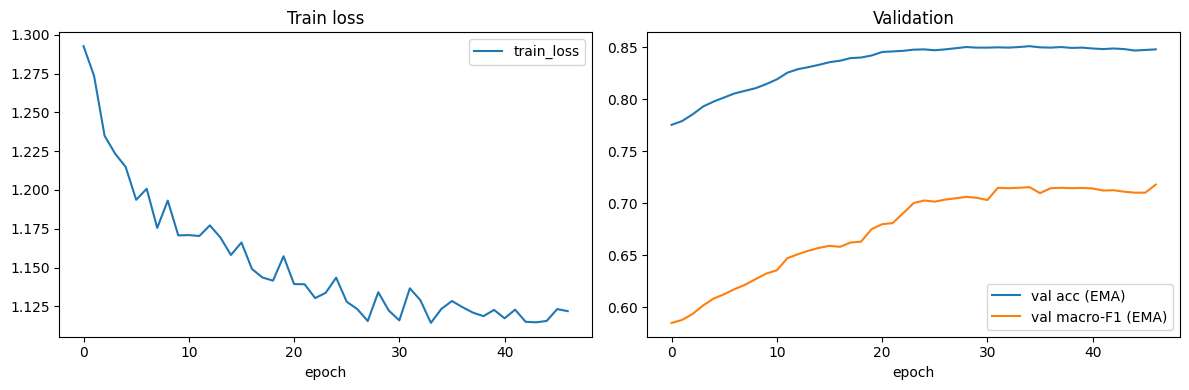

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_full['train_loss'], label='train_loss')
axes[0].set_title('Train loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(hist_full['val_acc'], label='val acc (EMA)')
axes[1].plot(hist_full['val_f1'],  label='val macro-F1 (EMA)')
axes[1].set_title('Validation'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()


## Test-time augmentation

Each test image is propagated through the model 16 times: original, horizontal
flip, five 92%-area crops (4 corners + center) each with and without flip, and two
multi-scale variants (0.95, 1.05) each with and without flip. Softmax is applied
to each forward pass and the resulting probability vectors are averaged. This
**soft-vote** within a single model averages out augmentation-induced calibration
shifts and is the per-model unit consumed later by the cross-model ensemble.

Test accuracy (TTA): 0.8493
Test macro-F1: 0.7002
              precision    recall  f1-score   support

     Neutral     0.8812    0.8501    0.8654      1274
       Happy     0.9391    0.9462    0.9426       929
    Surprise     0.8415    0.8831    0.8618       445
         Sad     0.6940    0.7220    0.7077       446
       Angry     0.8278    0.8405    0.8341       326
     Disgust     0.4286    0.6522    0.5172        23
        Fear     0.5978    0.5914    0.5946        93
    Contempt     0.5556    0.1852    0.2778        27

    accuracy                         0.8493      3563
   macro avg     0.7207    0.7088    0.7002      3563
weighted avg     0.8502    0.8493    0.8487      3563



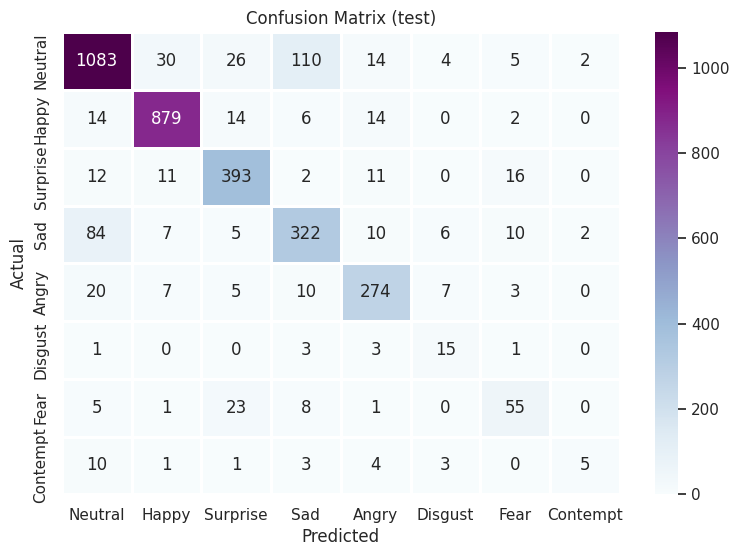

In [18]:
sns.set_theme(style="whitegrid")

def _five_crop(pv, crop_frac=0.92):
    H, W = pv.size(-2), pv.size(-1)
    ch = int(round(H*crop_frac)); cw = int(round(W*crop_frac))
    crops = [
        pv[..., :ch, :cw],
        pv[..., :ch, W-cw:],
        pv[..., H-ch:, :cw],
        pv[..., H-ch:, W-cw:],
        pv[..., (H-ch)//2:(H-ch)//2+ch, (W-cw)//2:(W-cw)//2+cw],
    ]
    return [F.interpolate(c, size=(H, W), mode='bilinear', align_corners=False) for c in crops]

def _scaled(pv, scale):
    H, W = pv.size(-2), pv.size(-1)
    nh, nw = int(round(H*scale)), int(round(W*scale))
    s = F.interpolate(pv, size=(nh, nw), mode='bilinear', align_corners=False)
    return F.interpolate(s, size=(H, W), mode='bilinear', align_corners=False)

@torch.inference_mode()
def predict_with_tta(loader, use_flip=True, use_5crop=True, use_scales=True):
    model.eval()
    yt_chunks, yp_chunks, probs_chunks = [], [], []
    use_amp = (DEVICE == 'cuda')
    def fwd(xdict):
        if use_amp:
            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                return model(**xdict).logits
        return model(**xdict).logits
    for xs, _, hy in loader:
        x = {k: v.to(DEVICE, non_blocking=True) for k,v in xs.items()}
        pv = x['pixel_values']
        ll = [fwd({'pixel_values': pv})]
        if use_flip: ll.append(fwd({'pixel_values': torch.flip(pv, dims=[-1])}))
        if use_5crop:
            for c in _five_crop(pv, 0.92):
                ll.append(fwd({'pixel_values': c}))
                if use_flip: ll.append(fwd({'pixel_values': torch.flip(c, dims=[-1])}))
        if use_scales:
            for s in (0.95, 1.05):
                sv = _scaled(pv, s)
                ll.append(fwd({'pixel_values': sv}))
                if use_flip: ll.append(fwd({'pixel_values': torch.flip(sv, dims=[-1])}))
        # Soft-vote: softmax then mean across augmentations.
        probs = torch.stack([F.softmax(z, dim=-1) for z in ll], dim=0).mean(dim=0)
        probs_chunks.append(probs.float().cpu().numpy())
        yp_chunks.append(probs.argmax(dim=1).cpu().numpy())
        yt_chunks.append(hy.numpy())
    return (np.concatenate(yt_chunks), np.concatenate(yp_chunks),
            np.concatenate(probs_chunks, axis=0))

y_true_val,  y_pred_val,  probs_val_v6  = predict_with_tta(val_loader)
y_true_test, y_pred_test, probs_test_v6 = predict_with_tta(test_loader)

acc = (y_true_test == y_pred_test).mean()
f1  = f1_score(y_true_test, y_pred_test, average='macro')
print(f'Test accuracy (TTA): {acc:.4f}')
print(f'Test macro-F1: {f1:.4f}')

print(classification_report(y_true_test, y_pred_test, labels=list(range(NUM_CLASSES)),
                            target_names=FERP_DISPLAY, digits=4))

cm = confusion_matrix(y_true_test, y_pred_test, labels=list(range(NUM_CLASSES)))
plt.figure(figsize=(9, 6))
c = pd.DataFrame(cm, index=FERP_DISPLAY, columns=FERP_DISPLAY)
sns.heatmap(c, linecolor='White', cmap='BuPu', linewidth=1, annot=True, fmt='')
plt.title('Confusion Matrix (test)'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()


## Output artifacts

The notebook produces two files on Drive consumed by `03_ensemble_inference.ipynb`:

- `fer_v6_ferplus_best.pt` — `{state_dict, val_acc, epoch}` with EMA weights.
- `fer_v6_probs_cache.npz` — cached probability tensors `probs_val_v6` and
  `probs_test_v6` (each `(N, 8)` after TTA) plus `yt_val` and `yt_test`.

In [19]:
np.savez_compressed(
    str(ckpt_dir / 'fer_v6_probs_cache.npz'),
    yt_val=y_true_val,
    yt_test=y_true_test,
    probs_val_v6=probs_val_v6,
    probs_test_v6=probs_test_v6,
)
print(f'Probability cache saved: {ckpt_dir / "fer_v6_probs_cache.npz"}')


Probability cache saved: /content/drive/MyDrive/checkpoints/fer_v6_probs_cache.npz
